# TrustLens — AI-Generated Profile Image Detector

Module 6.7 · Ali Ahmad (231667) · Air University Islamabad · FCAI 2025-26

## Background

A detector trained only on GAN fakes performs close to chance on diffusion images
(Midjourney, Stable Diffusion, DALL-E), because diffusion models leave a much weaker
fingerprint than GANs. The failure is asymmetric: training on diffusion still catches GANs,
but not the reverse (Corvi et al., 2022).

This notebook trains on a mixed corpus (GAN + diffusion + face-swap) and measures the
difference against a GAN-only baseline:

| Model | Trained on |
|---|---|
| A | GAN only |
| B | GAN + diffusion + face-swap |

## Pipeline

```
image -> Stage 0: human face present?  no -> "NOT A PERSON" (stop)
                   yes, crop the face
         Stage 1: frozen CLIP -> features -> classifier -> Real / AI-generated / Uncertain
```

CLIP is not trained. It is a frozen encoder that turns each image into a feature vector;
only a small classifier is trained on those features, which keeps the whole run under an
hour on a free T4.

Requires: Runtime > Change runtime type > T4 GPU

## 1. Mount Drive + check GPU

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print('GPU available :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name      :', torch.cuda.get_device_name(0))
else:
    print('!! NO GPU — Runtime > Change runtime type > T4 GPU, then re-run.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU available : True
GPU name      : Tesla T4


## 2. Settings

Data sources:
1. `140k Real and Fake Faces` (Kaggle) — real FFHQ faces and StyleGAN fakes.
2. `DeepFakeFace` (HuggingFace) — real wiki faces plus Stable Diffusion, inpainting and
   face-swap fakes.

In [4]:
OUT_DIR = '/content/drive/MyDrive/TrustLens/deepfake-scanner/artifacts'

# Images used per source. Defaults keep encoding to roughly 10-15 min.
N_REAL_TRAIN  = 12000   # each of: ffhq, wiki           -> 24k real train
N_FAKE_TRAIN  = 6000    # each of: stylegan, text2img, inpainting, insight -> 24k fake train
N_TEST        = 2000    # per source, held out

CLIP_ARCH = 'ViT-B-32'   # 'ViT-L-14' = stronger but ~4x slower
MIN_CONFIDENCE = 0.60    # below this the module says "Uncertain" instead of guessing

import os
os.makedirs(OUT_DIR, exist_ok=True)
print('Artifacts ->', OUT_DIR)

Artifacts -> /content/drive/MyDrive/TrustLens/deepfake-scanner/artifacts


In [5]:
# open_clip and facenet are installed without dependencies so they cannot downgrade the
# torch / torchvision / Pillow versions Colab already ships.
!pip -q install --no-deps open_clip_torch facenet-pytorch
!pip -q install -q ftfy regex huggingface_hub

import PIL, io, torch, torchvision
from PIL import Image
print('torch      ', torch.__version__)
print('torchvision', torchvision.__version__)
print('Pillow     ', PIL.__version__)

try:
    _b = io.BytesIO(); Image.new('RGB', (32, 32)).save(_b, 'JPEG', quality=80)
    print('Pillow JPEG encoder: OK')
except Exception as e:
    print('Pillow JPEG encoder unavailable, using OpenCV:', e)

import open_clip
print('open_clip OK ->', open_clip.__version__)

torch       2.2.2+cu121
torchvision 0.17.2+cu121
Pillow      10.2.0
Pillow JPEG encoder: OK
open_clip OK -> 3.3.0


## 3. Source 1 — 140k Real and Fake Faces

Downloaded inside Colab through the Kaggle API, which needs credentials from
kaggle.com/settings (API section). Set `GET_140K = 'drive'` to use a zip already stored in
Drive instead.

In [6]:
import glob, shutil, zipfile, time, os, subprocess, sys

# 'kaggle' = download inside Colab
# 'drive'  = use a zip stored in Google Drive
GET_140K = 'kaggle'

KAGGLE_DIR = '/content/data_140k'
os.makedirs(KAGGLE_DIR, exist_ok=True)

def _unzip(zpath, dest):
    if os.listdir(dest):
        print('already extracted'); return
    t = time.time(); print('unzipping...')
    with zipfile.ZipFile(zpath) as z:
        z.extractall(dest)
    print(f'  unzipped in {time.time()-t:.0f}s')


if GET_140K == 'kaggle':
    # Kaggle API credentials
    cred = '/root/.kaggle/kaggle.json'
    if not os.path.exists(cred):
        print('Upload kaggle.json  (kaggle.com/settings > API > Create New Token)')
        from google.colab import files as _f
        up = _f.upload()
        name = next((k for k in up if k.endswith('.json')), None)
        if not name:
            raise SystemExit('No .json uploaded. Get it at https://www.kaggle.com/settings')
        os.makedirs('/root/.kaggle', exist_ok=True)
        shutil.copy(name, cred)
        os.chmod(cred, 0o600)
        print('credentials installed')

    # Dataset download
    zpath = '/content/140k.zip'
    if not os.path.exists(zpath):
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'], check=False)
        print('\ndownloading 140k from Kaggle (~3.7 GB, usually 1-3 min)...')
        t = time.time()
        r = subprocess.run(
            ['kaggle', 'datasets', 'download', '-d', 'xhlulu/140k-real-and-fake-faces',
             '-p', '/content', '--force'],
            capture_output=True, text=True)
        print(r.stdout[-1500:])
        if r.returncode != 0:
            print(r.stderr[-1500:])
            raise SystemExit(
                'Kaggle download failed. Check that the account is phone-verified, that '
                'the dataset terms are accepted, and that the API token is current.')
        got = [p for p in glob.glob('/content/*.zip') if 'dff' not in p.lower()]
        if not got:
            raise SystemExit('Download reported success but no .zip was found.')
        newest = max(got, key=os.path.getmtime)
        if newest != zpath:
            os.rename(newest, zpath)
        print(f'  downloaded in {time.time()-t:.0f}s ({os.path.getsize(zpath)/1e9:.2f} GB)')
    _unzip(zpath, KAGGLE_DIR)

elif GET_140K == 'drive':
    zips = glob.glob('/content/drive/MyDrive/**/*.zip', recursive=True)
    if not zips:
        raise FileNotFoundError('No .zip in Drive. Use GET_140K = "kaggle" instead.')
    print('ZIPs in your Drive:')
    for i, z in enumerate(zips):
        print(f'  [{i}] {z}  ({os.path.getsize(z)/1e9:.2f} GB)')
    ZIP_INDEX = None                       # index into the list above, if needed
    src = zips[ZIP_INDEX] if ZIP_INDEX is not None else max(zips, key=os.path.getsize)
    print('\nUsing:', src)
    local = '/content/kaggle.zip'
    if not os.path.exists(local):
        t = time.time(); print('copying Drive -> local disk...')
        shutil.copy(src, local); print(f'  {time.time()-t:.0f}s')
    _unzip(local, KAGGLE_DIR)

else:
    raise SystemExit("GET_140K must be 'kaggle' or 'drive'")

print('\n140k ready at', KAGGLE_DIR)

already extracted

140k ready at /content/data_140k


## 4. Source 2 — DeepFakeFace (diffusion + face-swap), straight from HuggingFace

4 zips × 30,000 images (~5 GB total). This is the part that makes the detector work on
**2026-era** generators.

In [7]:
from huggingface_hub import hf_hub_download

DFF_DIR = '/content/dff'
os.makedirs(DFF_DIR, exist_ok=True)

DFF_FILES = {
    'wiki':       'wiki.zip',        # REAL   (IMDB-WIKI photos)
    'text2img':   'text2img.zip',    # FAKE   Stable Diffusion v1.5
    'inpainting': 'inpainting.zip',  # FAKE   SD inpainting
    'insight':    'insight.zip',     # FAKE   InsightFace face-swap
}

for name, fn in DFF_FILES.items():
    out = os.path.join(DFF_DIR, name)
    if os.path.isdir(out) and os.listdir(out):
        print(f'{name}: already extracted'); continue
    print(f'\n=== {name} ({fn}) ===')
    t = time.time()
    p = hf_hub_download(repo_id='OpenRL/DeepFakeFace', filename=fn,
                        repo_type='dataset', local_dir='/content/dff_zips')
    print(f'  downloaded in {time.time()-t:.0f}s')
    os.makedirs(out, exist_ok=True)
    t = time.time()
    with zipfile.ZipFile(p) as z: z.extractall(out)
    print(f'  unzipped in {time.time()-t:.0f}s')
    os.remove(p)                       # free disk immediately

print('\nDFF ready')

wiki: already extracted
text2img: already extracted
inpainting: already extracted
insight: already extracted

DFF ready


## 5. Build the file lists

Six sources, each split into train / test with **no overlap**. Splits are done per source so
the diffusion test set is genuinely unseen.

In [8]:
import random
random.seed(42)
IMG_EXT = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')

def find_images(root):
    out = []
    for r, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith(IMG_EXT):
                out.append(os.path.join(r, f))
    return out

# 140k: folders named real / fake
ffhq_files, stylegan_files = [], []
for r, dirs, _ in os.walk(KAGGLE_DIR):
    for d in dirs:
        if d.lower() == 'real':
            ffhq_files += find_images(os.path.join(r, d))
        elif d.lower() == 'fake':
            stylegan_files += find_images(os.path.join(r, d))

ffhq_files = sorted(set(ffhq_files))
stylegan_files = sorted(set(stylegan_files))

# ---- DFF ----
dff = {k: sorted(set(find_images(os.path.join(DFF_DIR, k)))) for k in DFF_FILES}

print('found images:')
print(f'  ffhq (real)      : {len(ffhq_files):,}')
print(f'  stylegan (GAN)   : {len(stylegan_files):,}')
for k, v in dff.items():
    print(f'  {k:16s} : {len(v):,}')

if not ffhq_files or not stylegan_files:
    print('\n!! 140k folders not found. Tree:')
    for r, dirs, files in os.walk(KAGGLE_DIR):
        if r.replace(KAGGLE_DIR, '').count(os.sep) <= 2:
            print('   ', r, f'({len(files)} files)')
    raise SystemExit('Fix paths above and re-run.')


def split(files, n_train, n_test):
    """Shuffle once, then take disjoint train / test slices."""
    f = list(files); random.shuffle(f)
    return f[n_test:n_test + n_train], f[:n_test]

N_FAKE_TOTAL = N_FAKE_TRAIN * 4          # model A draws its whole fake budget from StyleGAN

S = {}
S['ffhq_tr'], S['ffhq_te'] = split(ffhq_files,        N_REAL_TRAIN,  N_TEST)
S['wiki_tr'], S['wiki_te'] = split(dff['wiki'],       N_REAL_TRAIN,  N_TEST)
S['sgan_tr'], S['sgan_te'] = split(stylegan_files,    N_FAKE_TOTAL,  N_TEST)
S['t2i_tr'],  S['t2i_te']  = split(dff['text2img'],   N_FAKE_TRAIN,  N_TEST)
S['inp_tr'],  S['inp_te']  = split(dff['inpainting'], N_FAKE_TRAIN,  N_TEST)
S['ins_tr'],  S['ins_te']  = split(dff['insight'],    N_FAKE_TRAIN,  N_TEST)

print('\nsplit sizes:')
for k in sorted(S):
    print(f'  {k:10s} {len(S[k]):,}')

# train and test must not share a file
for a, b in [('ffhq_tr','ffhq_te'), ('wiki_tr','wiki_te'), ('sgan_tr','sgan_te'),
             ('t2i_tr','t2i_te'), ('inp_tr','inp_te'), ('ins_tr','ins_te')]:
    assert not (set(S[a]) & set(S[b])), f'LEAKAGE between {a} and {b}'
print('\nno train/test overlap  OK')

found images:
  ffhq (real)      : 70,000
  stylegan (GAN)   : 70,000
  wiki             : 30,000
  text2img         : 30,000
  inpainting       : 30,000
  insight          : 30,000

split sizes:
  ffhq_te    2,000
  ffhq_tr    12,000
  inp_te     2,000
  inp_tr     6,000
  ins_te     2,000
  ins_tr     6,000
  sgan_te    2,000
  sgan_tr    24,000
  t2i_te     2,000
  t2i_tr     6,000
  wiki_te    2,000
  wiki_tr    12,000

no train/test overlap  OK


## 6. Instagram-realistic degradation

Instagram serves profile pictures small (~150–320 px) and JPEG-compressed. Without this the
model would simply learn "clean image = real" and fail on every real profile picture.

## 7. Encode every source with frozen CLIP

Run once. Each source is encoded separately so the training sets can be composed from them
in the next cell.

JPEG backend: OpenCV


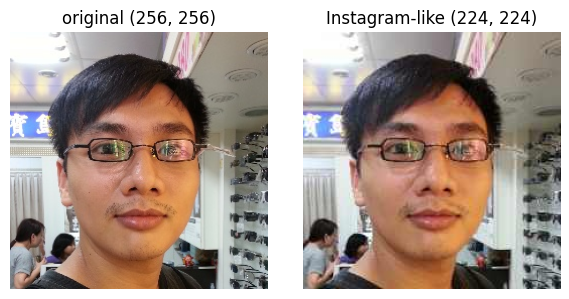

In [9]:
import io
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Some Colab package combinations leave Pillow's JPEG encoder broken while reading still
# works. OpenCV's encoder is independent of Pillow, so it is used when available.
try:
    import cv2
    _HAVE_CV2 = True
except Exception:
    _HAVE_CV2 = False

def jpeg_recompress(img, quality):
    """Round-trip an image through JPEG at the given quality."""
    img = img.convert('RGB')
    if _HAVE_CV2:
        arr = np.array(img)[:, :, ::-1]                      # RGB -> BGR
        ok, enc = cv2.imencode('.jpg', arr,
                               [int(cv2.IMWRITE_JPEG_QUALITY), int(quality)])
        if ok:
            dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)        # BGR
            return Image.fromarray(dec[:, :, ::-1])
    buf = io.BytesIO(); img.save(buf, 'JPEG', quality=quality); buf.seek(0)
    return Image.open(buf).convert('RGB')


def instagram_degrade(img, p=0.7):
    """Emulate an Instagram thumbnail: downscale and JPEG recompress."""
    img = img.convert('RGB')
    if random.random() > p:
        return img
    target = random.choice([128, 160, 224, 320])
    q = random.randint(40, 90)
    w, h = img.size
    s = target / max(w, h)
    if s < 1.0:
        img = img.resize((max(1, int(w*s)), max(1, int(h*s))), Image.BICUBIC)
    return jpeg_recompress(img, q)


print('JPEG backend:', 'OpenCV' if _HAVE_CV2 else 'Pillow')
demo = Image.open(S['ffhq_tr'][0])
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(demo); ax[0].set_title(f'original {demo.size}'); ax[0].axis('off')
d = instagram_degrade(demo, p=1.0)
ax[1].imshow(d); ax[1].set_title(f'Instagram-like {d.size}'); ax[1].axis('off')
plt.tight_layout(); plt.show()

In [10]:
import open_clip, numpy as np
from tqdm.auto import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
clip_model, _, preprocess = open_clip.create_model_and_transforms(CLIP_ARCH, pretrained='openai')
clip_model = clip_model.to(device).eval()
with torch.no_grad():
    FEAT_DIM = clip_model.encode_image(torch.zeros(1, 3, 224, 224).to(device)).shape[1]
print(f'{CLIP_ARCH} on {device} | feature dim {FEAT_DIM}')

@torch.no_grad()
def encode(files, augment, bs=64, desc=''):
    feats, batch = [], []
    def flush():
        if batch:
            x = torch.stack(batch).to(device)
            f = clip_model.encode_image(x)
            f = f / f.norm(dim=-1, keepdim=True)
            feats.append(f.cpu().numpy().astype('float32')); batch.clear()
    for fp in tqdm(files, desc=desc, leave=False):
        try:
            im = Image.open(fp)
            im = instagram_degrade(im) if augment else im.convert('RGB')
        except Exception:
            continue                      # unreadable file -> skipped
        batch.append(preprocess(im))
        if len(batch) >= bs: flush()
    flush()
    return np.concatenate(feats) if feats else np.zeros((0, FEAT_DIM), 'float32')

t0 = time.time()
F = {}
for key in sorted(S):
    aug = key.endswith('_tr')            # augment training data only
    F[key] = encode(S[key], augment=aug, desc=key)
    print(f'{key:10s} -> {F[key].shape}')
print(f'\ntotal encode time: {(time.time()-t0)/60:.1f} min')

np.savez_compressed(os.path.join(OUT_DIR, 'clip_features.npz'), **F)
print('features backed up to Drive (survives a disconnect)')

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


ViT-B-32 on cuda | feature dim 512


ffhq_te:   0%|          | 0/2000 [00:00<?, ?it/s]

...

t2i_tr     -> (6000, 512)


wiki_te:   0%|          | 0/2000 [00:00<?, ?it/s]

wiki_te    -> (2000, 512)


wiki_tr:   0%|          | 0/12000 [00:00<?, ?it/s]

wiki_tr    -> (12000, 512)

total encode time: 14.0 min
features backed up to Drive (survives a disconnect)


## 8. Experiment — effect of training-set diversity

Model A is trained on GAN fakes only. Model B is trained on GAN, diffusion and face-swap
fakes. Both use the same real images and the same total number of fakes, so the only
variable is the diversity of the fake class.

The diffusion test set contains generators model A never saw during training.

=== training sets (controlled) ===
A  real=24,000  fake=24,000  total=48,000   (GAN only)
B  real=24,000  fake=24,000  total=48,000   (mixed)
test GAN        real=2,000 fake=2,000
test DIFFUSION  real=2,000 fake=2,000
test FACE-SWAP  real=2,000 fake=2,000

probe A: MLP   |   probe B: MLP

A = GAN-only training (2020 approach)   |   B = mixed training (ours)
same real data, same number of fakes -- only fake DIVERSITY differs
      test set  A acc   A f1  A auc  B acc   B f1  B auc
GAN (StyleGAN) 0.9565 0.9565 0.9939 0.9323 0.9322 0.9846
DIFFUSION (SD) 0.5000 0.3347 0.6001 0.9400 0.9400 0.9872
     FACE-SWAP 0.5010 0.3369 0.5230 0.9052 0.9052 0.9668

>> On diffusion fakes:  A = 50.0%   B = 94.0%   (chance = 50.0%)

--- Model B on the diffusion test set ---
[[1829  171]
 [  69 1931]]
              precision    recall  f1-score   support

        real       0.96      0.91      0.94      2000
AI-generated       0.92      0.97      0.94      2000

    accuracy                           0.94 

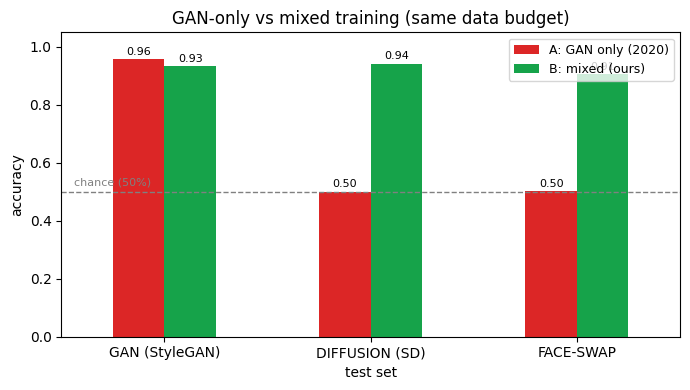

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
import joblib, pandas as pd

def stack(real_parts, fake_parts):
    """real_parts / fake_parts are lists of feature arrays."""
    Xr = np.concatenate(real_parts); Xf = np.concatenate(fake_parts)
    X = np.concatenate([Xr, Xf])
    # labels follow the encoded row counts, not the file-list lengths
    y = np.concatenate([np.zeros(len(Xr)), np.ones(len(Xf))])
    return X, y

# Both models get the same real images and the same total number of fakes, so the only
# variable is the diversity of the fake class.
REAL_TRAIN = [F['ffhq_tr'], F['wiki_tr']]
n_fake_each = len(F['t2i_tr'])                     # per-source budget for B

# A: all fakes from StyleGAN only
FAKE_A = [F['sgan_tr']]
# B: same total, spread across 4 generator families
FAKE_B = [F['sgan_tr'][:n_fake_each], F['t2i_tr'], F['inp_tr'], F['ins_tr']]

Xa, ya = stack(REAL_TRAIN, FAKE_A)
Xb, yb = stack(REAL_TRAIN, FAKE_B)

print('=== training sets (controlled) ===')
print(f'A  real={int((ya==0).sum()):,}  fake={int((ya==1).sum()):,}  total={len(ya):,}   (GAN only)')
print(f'B  real={int((yb==0).sum()):,}  fake={int((yb==1).sum()):,}  total={len(yb):,}   (mixed)')
if abs(int((ya==1).sum()) - int((yb==1).sum())) > 50:
    print('   NOTE: fake counts differ slightly (a source had fewer usable images).')

# Test sets are 50/50 real vs fake so accuracy is not inflated by imbalance.
half = len(F['wiki_te'])
X_gan,  y_gan  = stack([F['ffhq_te']], [F['sgan_te']])
X_diff, y_diff = stack([F['wiki_te']],
                       [F['t2i_te'][:half//2], F['inp_te'][:half//2]])   # unseen by model A
X_swap, y_swap = stack([F['wiki_te']], [F['ins_te']])

for nm, (X, y) in {'GAN': (X_gan, y_gan), 'DIFFUSION': (X_diff, y_diff),
                   'FACE-SWAP': (X_swap, y_swap)}.items():
    print(f'test {nm:10s} real={int((y==0).sum()):,} fake={int((y==1).sum()):,}')


def train_probe(X, y):
    sc = StandardScaler().fit(X)
    Xs = sc.transform(X)
    cands = {
        'LogisticRegression': LogisticRegression(max_iter=3000, C=1.0),
        'MLP': MLPClassifier(hidden_layer_sizes=(256,), max_iter=300,
                             early_stopping=True, random_state=42),
    }
    fitted = {n: c.fit(Xs, y) for n, c in cands.items()}
    # selected on training f1; test sets are untouched until evaluation
    name = max(fitted, key=lambda n: f1_score(y, fitted[n].predict(Xs), average='macro'))
    return fitted[name], sc, name

modelA, scA, nameA = train_probe(Xa, ya)
modelB, scB, nameB = train_probe(Xb, yb)
print(f'\nprobe A: {nameA}   |   probe B: {nameB}')


def ev(model, sc, X, y):
    p = model.predict_proba(sc.transform(X))[:, 1]
    pred = (p >= 0.5).astype(int)
    return (round(accuracy_score(y, pred), 4),
            round(f1_score(y, pred, average='macro'), 4),
            round(roc_auc_score(y, p), 4))

rows = []
for label, (X, y) in {'GAN (StyleGAN)': (X_gan, y_gan),
                      'DIFFUSION (SD)': (X_diff, y_diff),
                      'FACE-SWAP':      (X_swap, y_swap)}.items():
    a = ev(modelA, scA, X, y); b = ev(modelB, scB, X, y)
    rows.append({'test set': label,
                 'A acc': a[0], 'A f1': a[1], 'A auc': a[2],
                 'B acc': b[0], 'B f1': b[1], 'B auc': b[2]})

comparison = pd.DataFrame(rows)
print('\n' + '=' * 78)
print('A = GAN-only training (2020 approach)   |   B = mixed training (ours)')
print('same real data, same number of fakes -- only fake DIVERSITY differs')
print('=' * 78)
print(comparison.to_string(index=False))

d = comparison[comparison['test set'] == 'DIFFUSION (SD)'].iloc[0]
print(f"\n>> On diffusion fakes:  A = {d['A acc']:.1%}   B = {d['B acc']:.1%}"
      f"   (chance = 50.0%)")

print('\n--- Model B on the diffusion test set ---')
pB = modelB.predict(scB.transform(X_diff))
print(confusion_matrix(y_diff, pB))
print(classification_report(y_diff, pB, target_names=['real', 'AI-generated']))

plot_df = comparison.set_index('test set')[['A acc', 'B acc']]
plot_df.columns = ['A: GAN only (2020)', 'B: mixed (ours)']
ax = plot_df.plot(kind='bar', figsize=(7, 4), rot=0, color=['#dc2626', '#16a34a'])
ax.set_ylabel('accuracy'); ax.set_ylim(0, 1.05)
ax.axhline(0.5, ls='--', c='gray', lw=1, label='_nolegend_')
ax.text(0.02, 0.52, 'chance (50%)', color='gray', fontsize=8,
        transform=ax.get_yaxis_transform())
ax.set_title('GAN-only vs mixed training (same data budget)')
ax.legend(fontsize=9)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'experiment_A_vs_B.png'), dpi=150)
plt.show()

## 9. Robustness — does it survive small Instagram thumbnails?

Accuracy of the production model (B) as the image gets smaller and more compressed.

{'size_px': 320, 'jpeg_q': 90, 'accuracy': 0.9233, 'f1_macro': 0.9233}
{'size_px': 224, 'jpeg_q': 80, 'accuracy': 0.9017, 'f1_macro': 0.9017}
{'size_px': 160, 'jpeg_q': 70, 'accuracy': 0.8908, 'f1_macro': 0.8906}
{'size_px': 128, 'jpeg_q': 50, 'accuracy': 0.8917, 'f1_macro': 0.8916}
{'size_px': 96, 'jpeg_q': 40, 'accuracy': 0.695, 'f1_macro': 0.667}

  size_px  jpeg_q  accuracy  f1_macro
     320      90    0.9233    0.9233
     224      80    0.9017    0.9017
     160      70    0.8908    0.8906
     128      50    0.8917    0.8916
      96      40    0.6950    0.6670


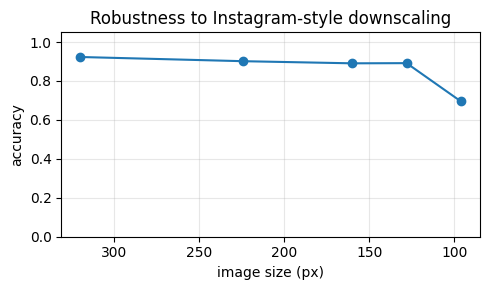

In [12]:
def encode_at(files, size, quality, bs=64):
    feats, batch = [], []
    @torch.no_grad()
    def flush():
        if batch:
            x = torch.stack(batch).to(device)
            f = clip_model.encode_image(x)
            f = f / f.norm(dim=-1, keepdim=True)
            feats.append(f.cpu().numpy().astype('float32')); batch.clear()
    for fp in files:
        try:
            im = Image.open(fp).convert('RGB')
        except Exception:
            continue
        w, h = im.size; s = size / max(w, h)
        if s < 1.0:
            im = im.resize((max(1, int(w*s)), max(1, int(h*s))), Image.BICUBIC)
        batch.append(preprocess(jpeg_recompress(im, quality)))
        if len(batch) >= bs: flush()
    flush()
    return np.concatenate(feats) if feats else np.zeros((0, FEAT_DIM), 'float32')

N = 600
real_probe = S['ffhq_te'][:N//2] + S['wiki_te'][:N//2]
fake_probe = S['t2i_te'][:N//3] + S['inp_te'][:N//3] + S['sgan_te'][:N//3]

rob = []
for size, q in [(320, 90), (224, 80), (160, 70), (128, 50), (96, 40)]:
    Xr = encode_at(real_probe, size, q); Xf = encode_at(fake_probe, size, q)
    X = scB.transform(np.concatenate([Xr, Xf]))
    y = np.concatenate([np.zeros(len(Xr)), np.ones(len(Xf))])
    pred = modelB.predict(X)
    rob.append({'size_px': size, 'jpeg_q': q,
                'accuracy': round(accuracy_score(y, pred), 4),
                'f1_macro': round(f1_score(y, pred, average='macro'), 4)})
    print(rob[-1])

rob_df = pd.DataFrame(rob)
print('\n', rob_df.to_string(index=False))
plt.figure(figsize=(5, 3))
plt.plot(rob_df['size_px'], rob_df['accuracy'], 'o-')
plt.gca().invert_xaxis(); plt.xlabel('image size (px)'); plt.ylabel('accuracy')
plt.ylim(0, 1.05); plt.grid(alpha=.3)
plt.title('Robustness to Instagram-style downscaling')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'robustness_curve.png'), dpi=130)
plt.show()

## 10. Save the production model (B) to Drive

In [13]:
import json

joblib.dump(modelB, os.path.join(OUT_DIR, 'image_probe.pkl'))
joblib.dump(scB,    os.path.join(OUT_DIR, 'image_scaler.pkl'))

meta = {
    'module': 'TrustLens 6.7 - AI-generated profile image detector',
    'clip_arch': CLIP_ARCH, 'clip_pretrained': 'openai',
    'feature_dim': int(FEAT_DIM),
    'classifier': nameB,
    'min_confidence': MIN_CONFIDENCE,
    'training_sources': {
        'real': ['FFHQ (140k Kaggle)', 'IMDB-WIKI (DeepFakeFace)'],
        'fake': ['StyleGAN (GAN)', 'Stable Diffusion v1.5', 'SD inpainting',
                 'InsightFace (face-swap)'],
    },
    'train_size': int(len(yb)),
    'experiment_A_vs_B': comparison.to_dict(orient='records'),
    'robustness': rob,
    'known_limitations': [
        'Diffusion fakes are Stable Diffusion; Midjourney/Flux are related but unseen.',
        'Non-face images return not_applicable.',
        'Very small faces return uncertain rather than a hard verdict.',
    ],
    'labels': {'0': 'real', '1': 'AI-generated'},
}
with open(os.path.join(OUT_DIR, 'image_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)
comparison.to_csv(os.path.join(OUT_DIR, 'experiment_A_vs_B.csv'), index=False)
rob_df.to_csv(os.path.join(OUT_DIR, 'robustness.csv'), index=False)

print('saved to', OUT_DIR)
for f in sorted(os.listdir(OUT_DIR)):
    print('  ', f, f'({os.path.getsize(os.path.join(OUT_DIR, f))/1024:.0f} KB)')

saved to /content/drive/MyDrive/TrustLens/deepfake-scanner/artifacts
   clip_features.npz (145179 KB)
   experiment_A_vs_B.csv (0 KB)
   experiment_A_vs_B.png (33 KB)
   image_meta.json (2 KB)
   image_probe.pkl (1548 KB)
   image_scaler.pkl (13 KB)
   robustness.csv (0 KB)
   robustness_curve.png (26 KB)


## 11. The full detector — face gate first, then the AI check

**Stage 0** looks for a human face. Pet, logo, landscape, object → `not_applicable`, and the
AI-check never runs. **Stage 1** runs only on the cropped face.

In [14]:
FACE_BACKEND = None
try:
    from facenet_pytorch import MTCNN
    _mtcnn = MTCNN(keep_all=True, device=device)
    FACE_BACKEND = 'mtcnn'
except Exception as e:
    print('MTCNN unavailable -> OpenCV fallback:', e)
    import cv2
    _cascade = cv2.CascadeClassifier(cv2.data.haarcascades +
                                     'haarcascade_frontalface_default.xml')
    FACE_BACKEND = 'opencv'
print('face backend:', FACE_BACKEND)


def detect_face(img):
    """Largest human face as (x1,y1,x2,y2), or None if there is no face."""
    img = img.convert('RGB')
    if FACE_BACKEND == 'mtcnn':
        boxes, probs = _mtcnn.detect(img)
        if boxes is None: return None
        keep = [(b, p) for b, p in zip(boxes, probs) if p is not None and p >= 0.90]
        if not keep: return None
        b, _ = max(keep, key=lambda t: (t[0][2]-t[0][0]) * (t[0][3]-t[0][1]))
        return tuple(float(v) for v in b)
    import numpy as _np, cv2
    g = cv2.cvtColor(_np.array(img), cv2.COLOR_RGB2GRAY)
    faces = _cascade.detectMultiScale(g, 1.1, 5)
    if len(faces) == 0: return None
    x, y, w, h = max(faces, key=lambda f: f[2]*f[3])
    return (float(x), float(y), float(x+w), float(y+h))


def crop_face(img, box, margin=0.35):
    """Crop with margin so framing matches the training faces."""
    img = img.convert('RGB')
    x1, y1, x2, y2 = box
    w, h = x2-x1, y2-y1
    mx, my = w*margin, h*margin
    return img.crop((max(0, int(x1-mx)), max(0, int(y1-my)),
                     min(img.width, int(x2+mx)), min(img.height, int(y2+my))))


@torch.no_grad()
def analyze_image(img, min_face_px=48):
    """Returns the verdict dict the Trust Score Engine consumes."""
    if isinstance(img, str): img = Image.open(img)
    img = img.convert('RGB')

    box = detect_face(img)                                   # ---- Stage 0 ----
    if box is None:
        return {'band': 'not_applicable', 'face_detected': False,
                'verdict': 'NOT A PERSON - no human face found',
                'confidence': None, 'p_ai': None, 'image_risk': None,
                'reason': 'Profile picture is not a human face (pet, logo, object or '
                          'scenery), so the AI-face check does not apply.'}

    face = crop_face(img, box)
    if min(face.size) < min_face_px:
        return {'band': 'uncertain', 'face_detected': True,
                'verdict': 'UNCERTAIN - face too small to judge',
                'confidence': None, 'p_ai': None, 'image_risk': None,
                'reason': f'Detected face is only {face.size[0]}x{face.size[1]} px.'}

    x = preprocess(face).unsqueeze(0).to(device)             # ---- Stage 1 ----
    f = clip_model.encode_image(x)
    f = (f / f.norm(dim=-1, keepdim=True)).cpu().numpy().astype('float32')
    p_ai = float(modelB.predict_proba(scB.transform(f))[0][1])
    conf = max(p_ai, 1 - p_ai)

    if conf < MIN_CONFIDENCE:   band, verdict = 'uncertain', 'UNCERTAIN - needs review'
    elif p_ai >= 0.5:           band, verdict = 'fake', 'AI-GENERATED FACE'
    else:                       band, verdict = 'real', 'REAL PHOTO'

    return {'band': band, 'verdict': verdict, 'face_detected': True,
            'confidence': round(conf, 4), 'p_ai': round(p_ai, 4),
            'image_risk': int(round(p_ai * 100)),
            'face_size': f'{face.size[0]}x{face.size[1]}',
            'reason': f'Face found and analysed; P(AI-generated)={p_ai:.1%}.'}

print('detector ready')

face backend: mtcnn
detector ready


## 12. Sanity check on held-out images

REAL (FFHQ)                -> REAL PHOTO                   conf=1.0
REAL (wiki)                -> REAL PHOTO                   conf=0.9999
FAKE - StyleGAN (GAN)      -> AI-GENERATED FACE            conf=0.9999
FAKE - Stable Diffusion    -> REAL PHOTO                   conf=0.999
FAKE - SD inpainting       -> AI-GENERATED FACE            conf=1.0
FAKE - face swap           -> AI-GENERATED FACE            conf=0.8432


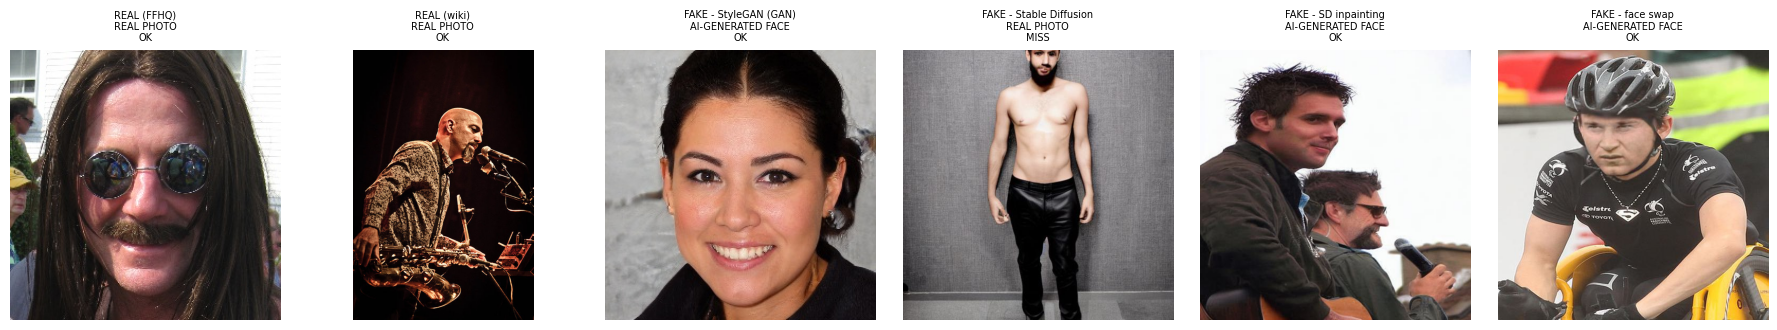

In [15]:
checks = [('REAL (FFHQ)',            S['ffhq_te'][0]),
          ('REAL (wiki)',            S['wiki_te'][0]),
          ('FAKE - StyleGAN (GAN)',  S['sgan_te'][0]),
          ('FAKE - Stable Diffusion',S['t2i_te'][0]),
          ('FAKE - SD inpainting',   S['inp_te'][0]),
          ('FAKE - face swap',       S['ins_te'][0])]

fig, axes = plt.subplots(1, len(checks), figsize=(3*len(checks), 3.4))
for ax, (label, path) in zip(axes, checks):
    r = analyze_image(path)
    ax.imshow(Image.open(path).convert('RGB')); ax.axis('off')
    ok = ('FAKE' in label and r['band'] == 'fake') or ('REAL' in label and r['band'] == 'real')
    ax.set_title(f"{label}\n{r['verdict']}\n{'OK' if ok else 'MISS'}", fontsize=7)
    print(f"{label:26s} -> {r['verdict']:28s} conf={r['confidence']}")
plt.tight_layout(); plt.show()

Saving images (3).jfif to images (3).jfif


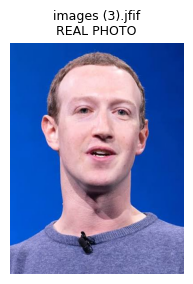

{
  "band": "real",
  "verdict": "REAL PHOTO",
  "face_detected": true,
  "confidence": 0.9841,
  "p_ai": 0.0159,
  "image_risk": 2,
  "face_size": "323x412",
  "reason": "Face found and analysed; P(AI-generated)=1.6%."
}
------------------------------------------------------------


In [19]:
# Classify uploaded images.
from google.colab import files
up = files.upload()

for name in up:
    img = Image.open(name)
    r = analyze_image(img)
    plt.figure(figsize=(3, 3)); plt.imshow(img.convert('RGB')); plt.axis('off')
    plt.title(f"{name}\n{r['verdict']}", fontsize=9); plt.show()
    print(json.dumps(r, indent=2)); print('-'*60)